In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

#used pandas for loading and analyzing the dataset.
#used numpy for numerical operations.
#used matplotlib and seaborn for graphs and visualization.
#used sklearn libraries for machine learning model training and evaluation.

In [40]:
df = pd.read_csv('/content/loan_predication.csv')

df.head()

#loaded the loan prediction dataset and displayed first 5 rows using head() function.

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [41]:
print("Shape of dataset:", df.shape)

#checked the shape of dataset showing total rows and columns.

Shape of dataset: (614, 13)


In [42]:
print("Columns in dataset:")
print(df.columns)

#displayed all column names present in the dataset.

Columns in dataset:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [43]:
df.info()

#used info() function to check datatype and non-null values in dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [44]:
df.describe()

#describe() function used to get statistical information like mean, min, max and standard deviation.

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [45]:
print(df.isnull().sum())

#checked if there is any missing value in the dataset using isnull() function.
#all columns are showing 0 which means there are no missing values present.
#dataset is already clean and ready for analysis.

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [47]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

#filled missing categorical values using mode.
#filled missing numerical values using median.

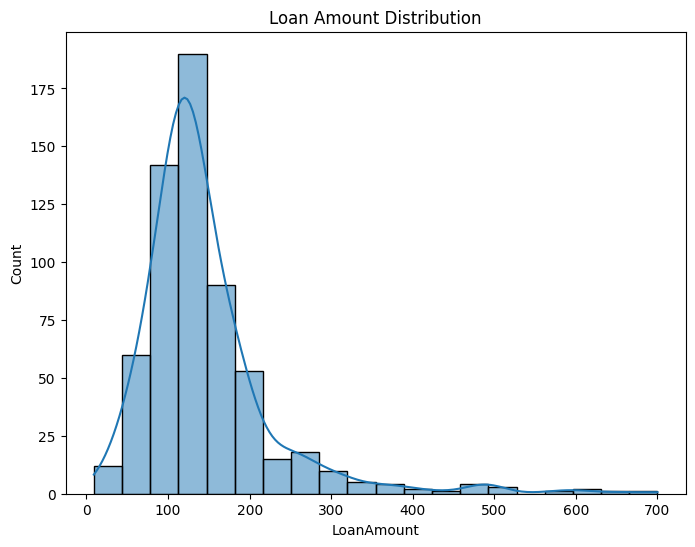

In [58]:
plt.figure(figsize=(8,6))

sns.histplot(df['LoanAmount'], bins=20, kde=True)

plt.title("Loan Amount Distribution")

plt.show()

#showing the distribution of loan amount values.
#most applicants are applying for loan amounts between 100 to 200.
#few applicants are applying for very high loan amounts.
#curve is showing the overall distribution pattern of loan amounts.

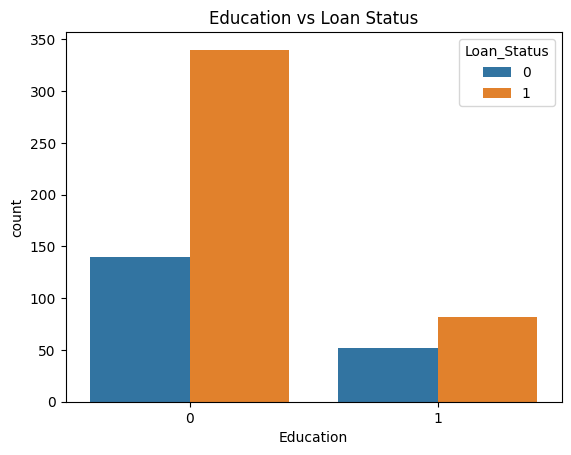

In [59]:
sns.countplot(x='Education', hue='Loan_Status', data=df)

plt.title("Education vs Loan Status")

plt.show()

#used to compare education level with loan approval status.
#graduates have more loan approvals compared to non-graduates.
#loan rejection count is lower than approval count for both groups.

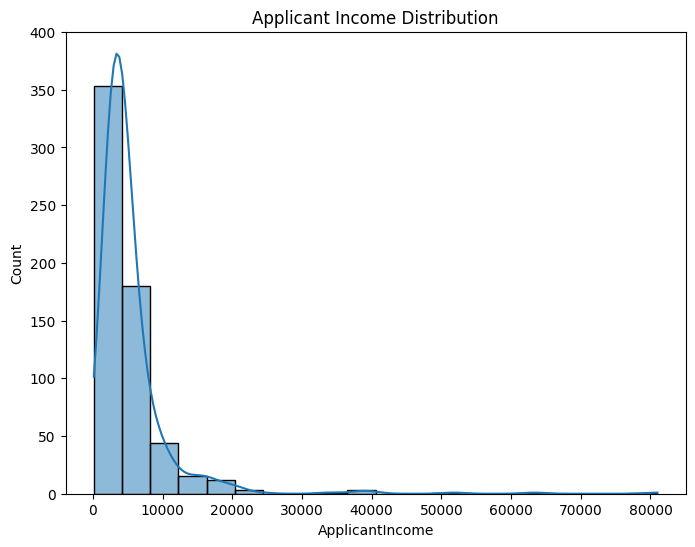

In [60]:
plt.figure(figsize=(8,6))

sns.histplot(df['ApplicantIncome'], bins=20, kde=True)

plt.title("Applicant Income Distribution")

plt.show()

#showing the distribution of applicant income values.
#most applicants have low to medium income values.
#very few applicants have extremely high income.
#curve is showing the income distribution pattern.s.

In [51]:
label_encoder = LabelEncoder()

categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

#converted categorical text values into numerical values using label encoding.
#machine learning models cannot directly work on text data.

In [52]:
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)

y = df['Loan_Status']

#removed Loan_ID because it is only an identification column.
#X contains all input features.
#y contains the target variable which is loan approval status.

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#split the dataset into training and testing data.
#80% data used for training and 20% data used for testing.

In [54]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

#trained the logistic regression model using training data.
#used logistic regression because this is a binary classification problem.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [55]:
y_pred = model.predict(X_test)

#predicted loan approval status using testing data.

In [62]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

#model achieved around 78% accuracy on testing data.
#accuracy tells how many predictions are correct out of total predictions.
#higher accuracy indicates better model performance.

Accuracy: 0.7886178861788617


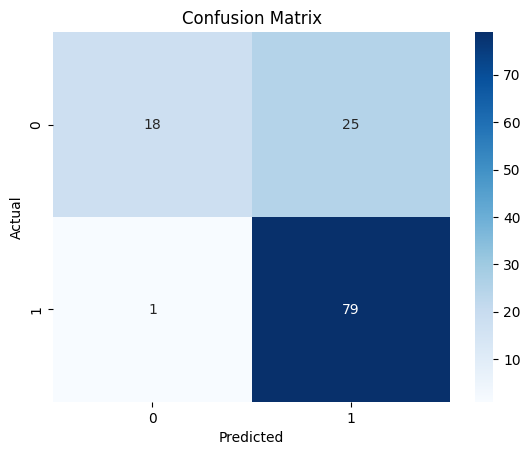

In [61]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

#used confusion matrix to check correct and incorrect predictions.
#diagonal values represent correct predictions made by the model.
#model predicted most loan approvals correctly.
#few incorrect predictions are also present.

In [63]:
#FINAL CONCLUSION:

#successfully predicted loan approval using logistic regression model.
#performed data cleaning, visualization and model evaluation.
#education, income and loan amount affected loan approval status.
#model achieved good accuracy using classification techniques.